# **Student Failure Risk**
**Goal: Predict students at risk of academic probation *(Binary Classification)***

## **1. Imports & Configuration**

In [3]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from matplotlib import rcParams
rcParams['figure.figsize'] = (12, 5)
rcParams['axes.facecolor']    = '#f8f9fa'
rcParams['figure.facecolor']  = 'white'
rcParams['axes.grid']         = True
rcParams['grid.alpha']        = 0.3
rcParams['axes.edgecolor']    = '#333333'
rcParams['axes.linewidth']    = 1.2
rcParams['font.family']       = 'sans-serif'
rcParams['font.size']         = 11
rcParams['axes.labelsize']    = 12
rcParams['axes.titlesize']    = 14
rcParams['axes.titleweight']  = 'bold'

COLORS  = ['#2C58BF', '#4E98DD', '#7DC0FF', '#AADCFF', '#18649A', '#003546']
CONFIG  = {
    'DB_PATH'     : '../data/edu_exam.sqlite',
    'TARGET'      : 'probation_flag',
    'TEST_SIZE'   : 0.20,
    'N_FOLDS'     : 5,
    'RANDOM_SEED' : 42,
}

## **2. Load Data**

In [4]:
con = sqlite3.connect(CONFIG['DB_PATH'])
cur = con.cursor()

table_list = [r[0] for r in cur.execute("SELECT name FROM sqlite_master WHERE type='table'")]
datasets   = {name: pd.read_sql(f"SELECT * FROM {name}", con) for name in table_list}

enrollments    = datasets['enrollments']
offerings      = datasets['course_offerings']
outcomes       = datasets['outcomes_semester']
attendance     = datasets['attendance']
lms            = datasets['lms_interactions']
behavior       = datasets['behavior_metrics']
integrity      = datasets['exam_integrity']
grades         = datasets['grades']
assessments    = datasets['assessments']
students       = datasets['students']
study_plan     = datasets['study_plan_targets']

print('Tables loaded:', list(datasets.keys()))

Tables loaded: ['semesters', 'students', 'courses', 'course_prereqs', 'course_offerings', 'enrollments', 'assessments', 'grades', 'attendance', 'lms_interactions', 'behavior_metrics', 'exam_integrity', 'student_skills', 'course_skills', 'study_plan_targets', 'outcomes_semester']


## **3. Build the Bridge**

The bridge maps `enrollment_id → (student_id, semester_id)` so we can aggregate everything up.

In [5]:
bridge = (
    enrollments[['enrollment_id', 'student_id', 'offering_id']]
    .merge(offerings[['offering_id', 'semester_id', 'course_id']], on='offering_id')
    [['enrollment_id', 'student_id', 'semester_id']]
)

print(f'Bridge shape: {bridge.shape}')
print(f'Unique student-semesters: {bridge[["student_id","semester_id"]].drop_duplicates().shape[0]}')
bridge.head()

Bridge shape: (3920, 3)
Unique student-semesters: 880


,enrollment_id,student_id,semester_id
0,1,S0001,2023_Fall
1,2,S0001,2023_Fall
2,3,S0001,2023_Fall
3,4,S0002,2023_Fall
4,5,S0002,2023_Fall


## **4. Feature Engineering**

#### 4.1 Attendance Features

In [6]:
att = attendance.merge(bridge, on='enrollment_id')
att['is_present'] = (att['status'] == 'Present').astype(int)
att['is_absent']  = (att['status'] == 'Absent').astype(int)
att['is_late']    = (att['status'] == 'Late').astype(int)

att_feat = att.groupby(['student_id', 'semester_id']).agg(
    att_rate  = ('is_present', 'mean'),
    abs_count = ('is_absent',  'sum'),
    late_rate = ('is_late',    'mean'),
).reset_index()

# Attendance trend: did the student show up less as the semester progressed?
def att_trend(grp):
    mid   = grp['week'].max() // 2
    early = grp[grp['week'] <= mid]['is_present'].mean()
    late  = grp[grp['week'] >  mid]['is_present'].mean()
    return pd.Series({'att_trend': late - early})

att_feat = att_feat.merge(
    att.groupby(['student_id', 'semester_id']).apply(att_trend).reset_index(),
    on=['student_id', 'semester_id']
)

print(f'att_feat shape: {att_feat.shape}')
att_feat.head()

att_feat shape: (880, 6)


,student_id,semester_id,att_rate,abs_count,late_rate,att_trend
0,S0001,2023_Fall,0.880952,1,0.095238,-0.142857
1,S0001,2024_Fall,0.916667,3,0.047619,0.119048
2,S0001,2024_Spring,0.875000,5,0.035714,-0.107143
3,S0001,2025_Spring,0.957143,2,0.014286,0.028571
4,S0002,2023_Fall,0.892857,3,0.053571,-0.071429


#### 4.2 LMS Features

In [7]:
lms_m = lms.merge(bridge, on='enrollment_id')

lms_feat = lms_m.groupby(['student_id', 'semester_id']).agg(
    pageview_mean        = ('pageviews',        'mean'),
    minutes_watched_mean = ('minutes_watched',   'mean'),
    forum_posts_sum      = ('forum_posts',       'sum'),
    quiz_attempts_sum    = ('quiz_attempts',     'sum'),
).reset_index()

# Engagement trends over weeks
def lms_trend(grp):
    if len(grp) < 2:
        return pd.Series({'pv_trend': 0, 'mw_trend': 0})
    return pd.Series({
        'pv_trend': np.polyfit(grp['week'], grp['pageviews'],        1)[0],
        'mw_trend': np.polyfit(grp['week'], grp['minutes_watched'],  1)[0],
    })

lms_feat = lms_feat.merge(
    lms_m.groupby(['student_id', 'semester_id']).apply(lms_trend).reset_index(),
    on=['student_id', 'semester_id']
)

print(f'lms_feat shape: {lms_feat.shape}')
lms_feat.head()

lms_feat shape: (880, 8)


,student_id,semester_id,pageview_mean,minutes_watched_mean,forum_posts_sum,quiz_attempts_sum,pv_trend,mw_trend
0,S0001,2023_Fall,22.619048,55.761905,21,28,0.473260,-1.375824
1,S0001,2024_Fall,27.154762,63.476190,57,95,0.392308,-0.187546
2,S0001,2024_Spring,25.553571,60.000000,39,58,0.075275,0.256044
3,S0001,2025_Spring,31.285714,74.214286,59,92,0.023736,0.670330
4,S0002,2023_Fall,24.410714,59.696429,50,61,-0.032418,1.504945


#### 4.3 Behavior Features

In [8]:
beh = behavior.merge(bridge, on='enrollment_id')

beh_feat = beh.groupby(['student_id', 'semester_id']).agg(
    engagement_mean = ('engagement',        'mean'),
    attention_mean  = ('attention',         'mean'),
    inactivity_mean = ('inactivity_minutes','mean'),
).reset_index()

print(f'beh_feat shape: {beh_feat.shape}')
beh_feat.head()

beh_feat shape: (880, 5)


,student_id,semester_id,engagement_mean,attention_mean,inactivity_mean
0,S0001,2023_Fall,0.429121,0.441289,30.833333
1,S0001,2024_Fall,0.511712,0.495354,29.154762
2,S0001,2024_Spring,0.510905,0.499523,30.464286
3,S0001,2025_Spring,0.619002,0.603977,22.400000
4,S0002,2023_Fall,0.510954,0.505678,29.250000


#### 4.4 Exam Integrity Features

In [9]:
integ = integrity.merge(bridge, on='enrollment_id')

integ_feat = integ.groupby(['student_id', 'semester_id']).agg(
    similarity_mean = ('similarity_score', 'mean'),
    jump_flags      = ('sudden_jump_flag', 'sum'),
    proctor_flags   = ('proctoring_flags', 'sum'),
).reset_index()

print(f'integ_feat shape: {integ_feat.shape}')
integ_feat.head()

integ_feat shape: (880, 5)


,student_id,semester_id,similarity_mean,jump_flags,proctor_flags
0,S0001,2023_Fall,0.098351,0,4
1,S0001,2024_Fall,0.117707,0,6
2,S0001,2024_Spring,0.141367,0,3
3,S0001,2025_Spring,0.121991,0,4
4,S0002,2023_Fall,0.104653,0,7


#### 4.5 Grade Features

In [10]:
grades_m = (
    grades
    .merge(assessments, on='assessment_id')
    .merge(bridge,      on='enrollment_id')
)
grades_m['weighted'] = grades_m['score'] * grades_m['weight']

grade_feat = (
    grades_m
    .groupby(['student_id', 'semester_id'])['weighted']
    .mean()
    .reset_index()
    .rename(columns={'weighted': 'avg_score'})
)

print(f'grade_feat shape: {grade_feat.shape}')
grade_feat.head()

grade_feat shape: (880, 3)


,student_id,semester_id,avg_score
0,S0001,2023_Fall,10.756779
1,S0001,2024_Fall,10.042841
2,S0001,2024_Spring,10.996970
3,S0001,2025_Spring,12.095862
4,S0002,2023_Fall,11.633187


#### 4.6 Student Profile Features

In [11]:
students['year_of_study'] = students['year_of_study'].apply(
    lambda x: int.from_bytes(x, byteorder='little') if isinstance(x, (bytes, bytearray)) else x
)

stud_feat = (
    students[['student_id', 'year_of_study', 'motivation_score', 'stress_level']]
    .merge(study_plan[['student_id', 'target_gpa', 'risk_tolerance']], on='student_id', how='left')
)

print(f'stud_feat shape: {stud_feat.shape}')
stud_feat.head()

stud_feat shape: (220, 6)


,student_id,year_of_study,motivation_score,stress_level,target_gpa,risk_tolerance
0,S0001,3,0.402325,0.646603,3.123191,3
1,S0002,1,0.571278,0.206283,2.324913,1
2,S0003,1,0.664565,0.388390,3.003820,3
3,S0004,1,0.389217,0.449067,3.020767,2
4,S0005,1,0.504959,0.569239,3.178720,4


#### 4.7 Assemble Final Dataset

In [12]:
df = outcomes[['student_id', 'semester_id', 'gpa', 'probation_flag']].copy()
df = df.sort_values(['student_id', 'semester_id'])

# Lagged GPA
df['prev_gpa']          = df.groupby('student_id')['gpa'].shift()
df['is_first_semester'] = df['prev_gpa'].isna().astype(int)
df['prev_gpa']          = df['prev_gpa'].fillna(0)

df = df.drop(columns=['gpa'])

for feat_df in [att_feat, lms_feat, beh_feat, integ_feat, grade_feat]:
    df = df.merge(feat_df, on=['student_id', 'semester_id'], how='left')

df = df.merge(stud_feat, on='student_id', how='left')
df = df.dropna().reset_index(drop=True)

feature_cols = [c for c in df.columns if c not in ['student_id', 'semester_id', 'probation_flag']]

print(f'Final dataset shape : {df.shape}')
print(f'Features            : {len(feature_cols)}')
print(f'Probation rate      : {df["probation_flag"].mean():.2%}')
df.head()

Final dataset shape : (880, 27)
Features            : 24
Probation rate      : 69.32%


,student_id,semester_id,probation_flag,prev_gpa,is_first_semester,att_rate,abs_count,late_rate,att_trend,pageview_mean,...,inactivity_mean,similarity_mean,jump_flags,proctor_flags,avg_score,year_of_study,motivation_score,stress_level,target_gpa,risk_tolerance
0,S0001,2023_Fall,1,0.00,1,0.880952,1,0.095238,-0.142857,22.619048,...,30.833333,0.098351,0,4,10.756779,3,0.402325,0.646603,3.123191,3
1,S0001,2024_Fall,1,1.67,0,0.916667,3,0.047619,0.119048,27.154762,...,29.154762,0.117707,0,6,10.042841,3,0.402325,0.646603,3.123191,3
2,S0001,2024_Spring,1,0.75,0,0.875000,5,0.035714,-0.107143,25.553571,...,30.464286,0.141367,0,3,10.996970,3,0.402325,0.646603,3.123191,3
3,S0001,2025_Spring,0,1.75,0,0.957143,2,0.014286,0.028571,31.285714,...,22.400000,0.121991,0,4,12.095862,3,0.402325,0.646603,3.123191,3
4,S0002,2023_Fall,1,0.00,1,0.892857,3,0.053571,-0.071429,24.410714,...,29.250000,0.104653,0,7,11.633187,1,0.571278,0.206283,2.324913,1


## **5. EDA**

### 5.1 Target Distribution

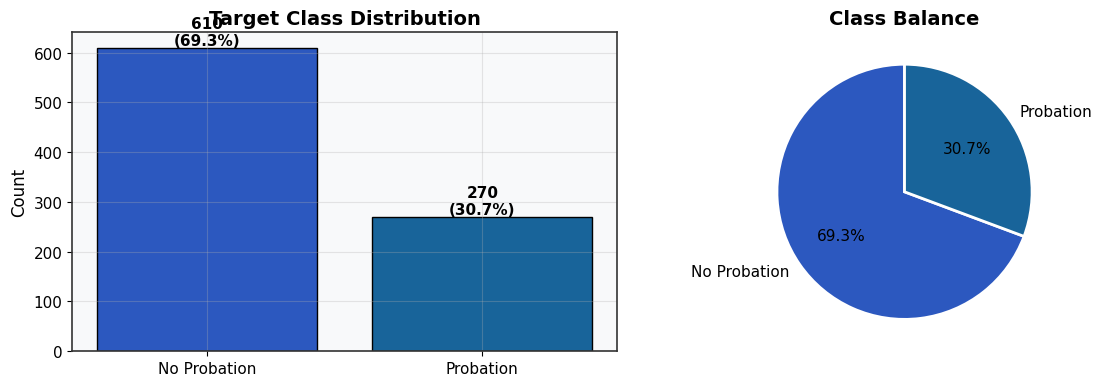

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['probation_flag'].value_counts()
axes[0].bar(['No Probation', 'Probation'], counts.values, color=[COLORS[0], COLORS[4]], edgecolor='black', linewidth=1)
for i, (bar, val) in enumerate(zip(axes[0].patches, counts.values)):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{val}\n({val/len(df):.1%})', ha='center', fontweight='bold')
axes[0].set_title('Target Class Distribution')
axes[0].set_ylabel('Count')

axes[1].pie(counts.values, labels=['No Probation', 'Probation'],
            colors=[COLORS[0], COLORS[4]], autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Balance')

plt.tight_layout()
plt.show()

### 5.2 Key Features vs Target

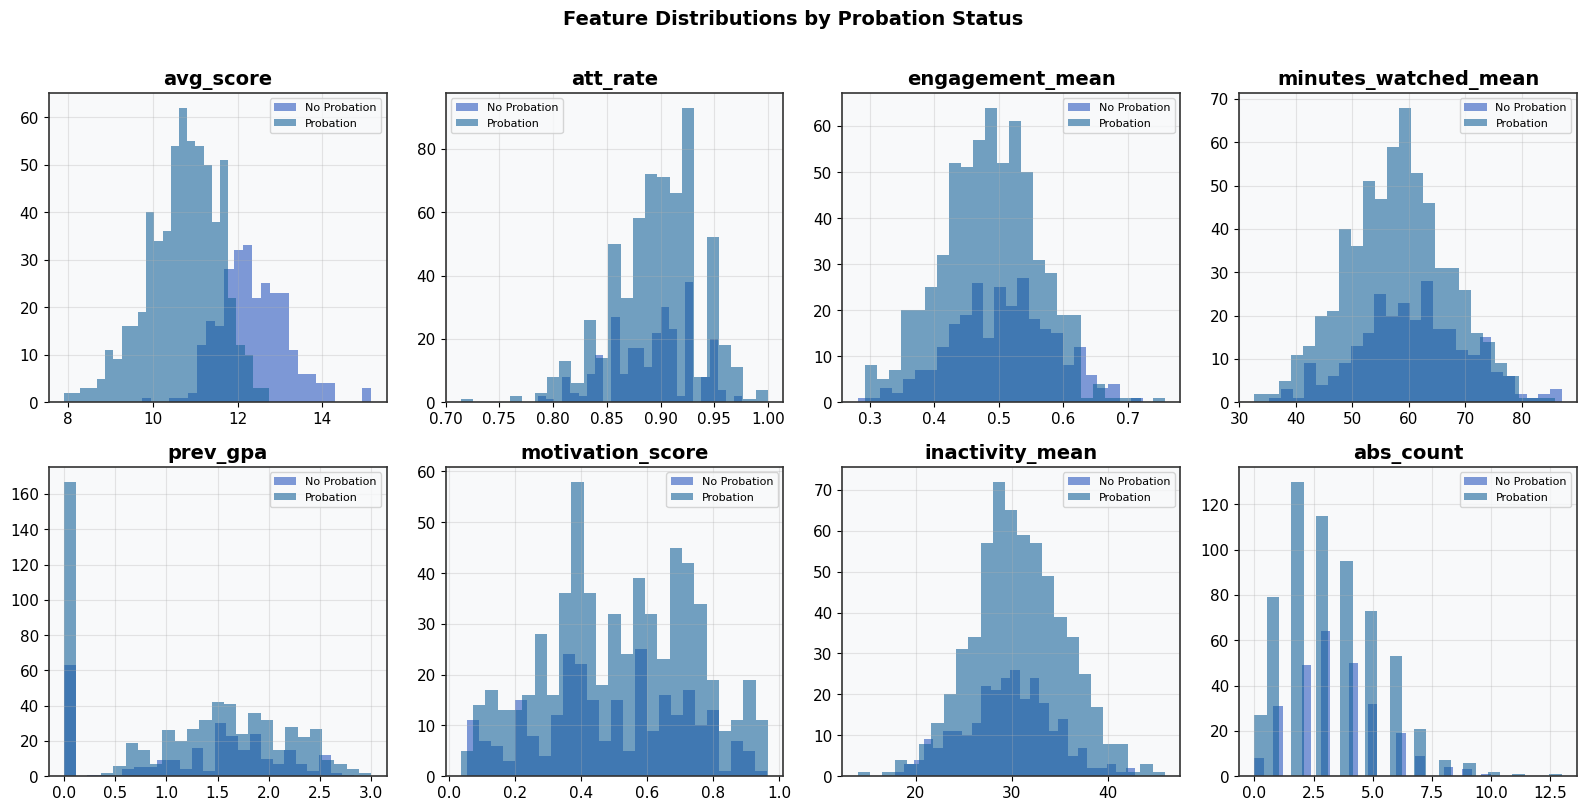

In [14]:
key_features = ['avg_score', 'att_rate', 'engagement_mean', 'minutes_watched_mean',
                'prev_gpa', 'motivation_score', 'inactivity_mean', 'abs_count']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    for flag, label, color in [(0, 'No Probation', COLORS[0]), (1, 'Probation', COLORS[4])]:
        axes[i].hist(df[df['probation_flag'] == flag][feat].dropna(),
                     bins=25, alpha=0.6, label=label, color=color, edgecolor='none')
    axes[i].set_title(feat, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('')

plt.suptitle('Feature Distributions by Probation Status', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 5.3 Correlation Heatmap

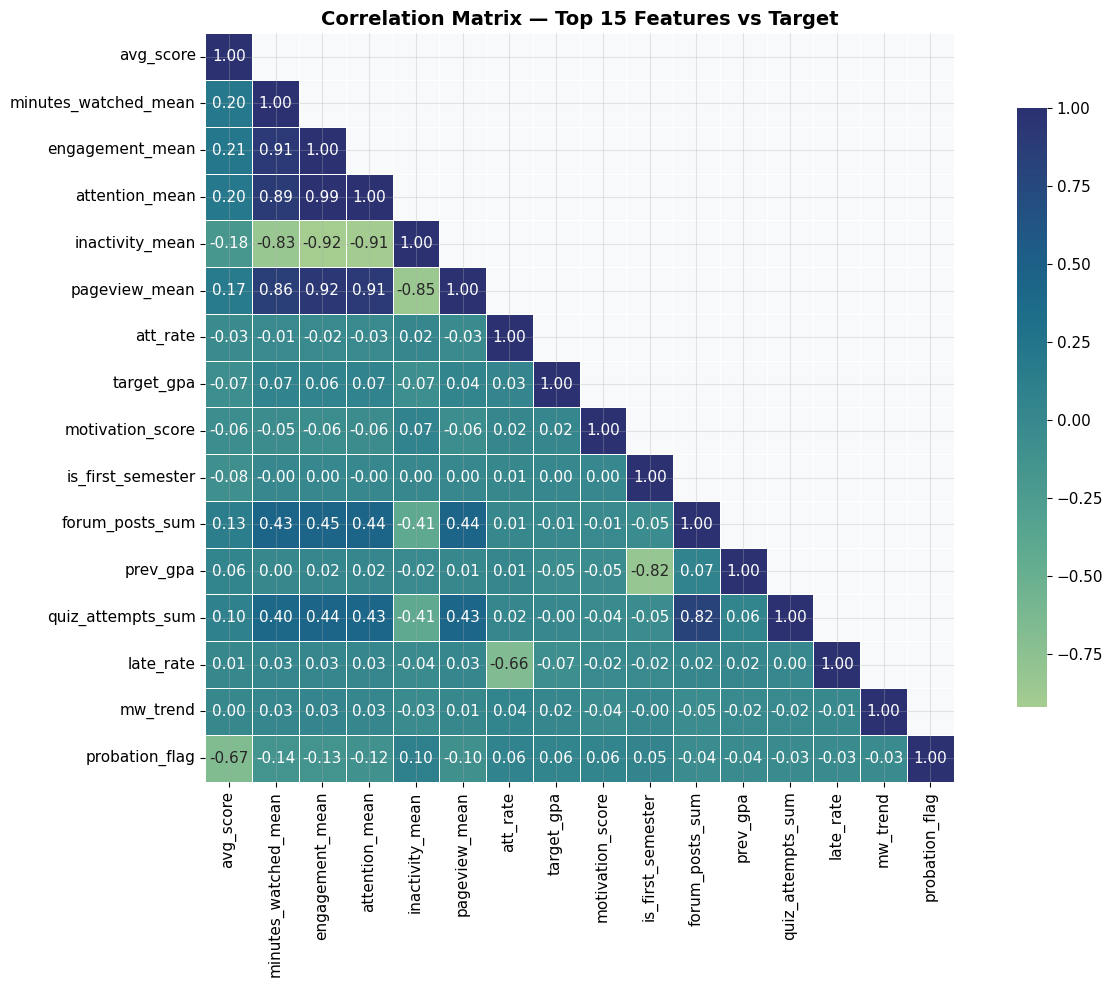

In [15]:
corr = df[feature_cols + ['probation_flag']].corr()

# Sort by correlation with target
target_corr_order = corr['probation_flag'].drop('probation_flag').abs().sort_values(ascending=False).index
top_cols = list(target_corr_order[:15]) + ['probation_flag']

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr.loc[top_cols, top_cols], dtype=bool), k=1)
sns.heatmap(corr.loc[top_cols, top_cols], mask=mask, annot=True, fmt='.2f',
            cmap='crest', square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — Top 15 Features vs Target', fontweight='bold')
plt.tight_layout()
plt.show()

## **6. Modelling**

### 6.1 Train / Test Split

In [18]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from imblearn.over_sampling import SMOTE

X = df[feature_cols]
y = df['probation_flag']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = CONFIG['TEST_SIZE'],
    stratify     = y,
    random_state = CONFIG['RANDOM_SEED']
)

smote = SMOTE(sampling_strategy='minority', random_state=CONFIG['RANDOM_SEED'])
X_train, y_train = smote.fit_resample(X_train, y_train)

cv = StratifiedKFold(n_splits=CONFIG['N_FOLDS'], shuffle=True, random_state=CONFIG['RANDOM_SEED'])

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Train probation rate: {y_train.mean():.2%}  |  Test: {y_test.mean():.2%}')

Train: (976, 24)  |  Test: (176, 24)
Train probation rate: 50.00%  |  Test: 69.32%


### 6.2 Baseline Comparison

In [19]:
from sklearn.linear_model  import LogisticRegression
from sklearn.tree          import DecisionTreeClassifier
from sklearn.ensemble      import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics       import roc_auc_score, f1_score, precision_score, recall_score

MODELS = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, C=0.5),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=6, random_state=CONFIG['RANDOM_SEED']),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, random_state=CONFIG['RANDOM_SEED']),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, random_state=CONFIG['RANDOM_SEED']),
}

results = {}
for name, model in MODELS.items():
    auc  = cross_val_score(model, X, y, cv=cv, scoring='roc_auc').mean()
    f1   = cross_val_score(model, X, y, cv=cv, scoring='f1').mean()
    prec = cross_val_score(model, X, y, cv=cv, scoring='precision').mean()
    rec  = cross_val_score(model, X, y, cv=cv, scoring='recall').mean()
    results[name] = {'AUC': auc, 'F1': f1, 'Precision': prec, 'Recall': rec}

results_df = pd.DataFrame(results).T.sort_values('AUC', ascending=False)
print(results_df.round(4).to_string())

                        AUC      F1  Precision  Recall
Logistic Regression  0.9222  0.8994     0.8850  0.9148
Gradient Boosting    0.9095  0.8902     0.8719  0.9098
Random Forest        0.9065  0.9016     0.8756  0.9295
Decision Tree        0.8448  0.8631     0.8487  0.8787


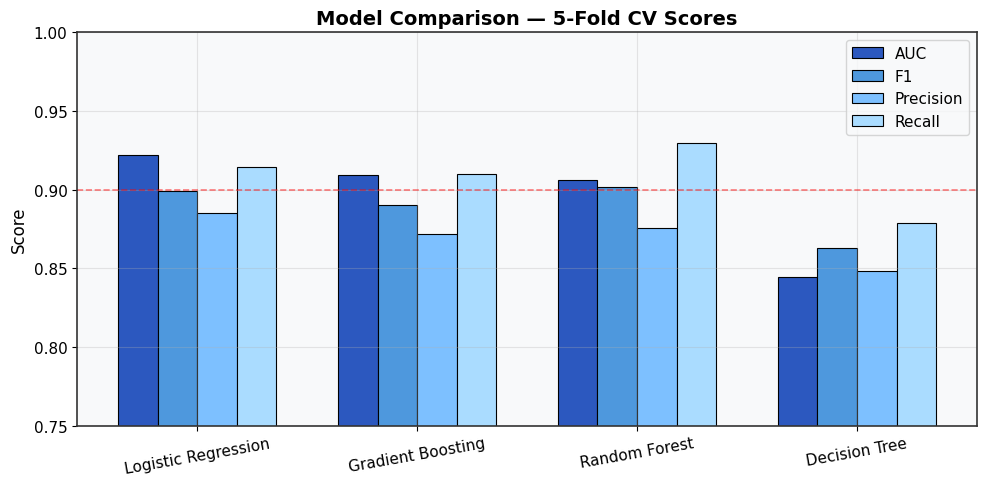

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
x    = np.arange(len(results_df))
w    = 0.18
metrics = ['AUC', 'F1', 'Precision', 'Recall']

for i, (metric, color) in enumerate(zip(metrics, COLORS)):
    bars = ax.bar(x + i*w, results_df[metric], width=w, label=metric,
                  color=color, edgecolor='black', linewidth=0.8)

ax.set_xticks(x + w*1.5)
ax.set_xticklabels(results_df.index, rotation=10)
ax.set_ylim(0.75, 1.0)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — 5-Fold CV Scores', fontweight='bold')
ax.legend()
ax.axhline(0.9, color='red', linestyle='--', alpha=0.5, linewidth=1.2, label='AUC=0.90 reference')
plt.tight_layout()
plt.show()

### 6.3 Best Model

In [21]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    RocCurveDisplay, PrecisionRecallDisplay
)

best_model = LogisticRegression(max_iter=1000, C=0.5)   # highest CV AUC
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print('=' * 55)
print('  TEST SET — CLASSIFICATION REPORT')
print('=' * 55)
print(classification_report(y_test, y_pred, target_names=['No Probation', 'Probation']))
print(f'  ROC-AUC : {roc_auc_score(y_test, y_prob):.4f}')

  TEST SET — CLASSIFICATION REPORT
              precision    recall  f1-score   support

No Probation       0.72      0.81      0.77        54
   Probation       0.91      0.86      0.89       122

    accuracy                           0.85       176
   macro avg       0.82      0.84      0.83       176
weighted avg       0.85      0.85      0.85       176

  ROC-AUC : 0.9106


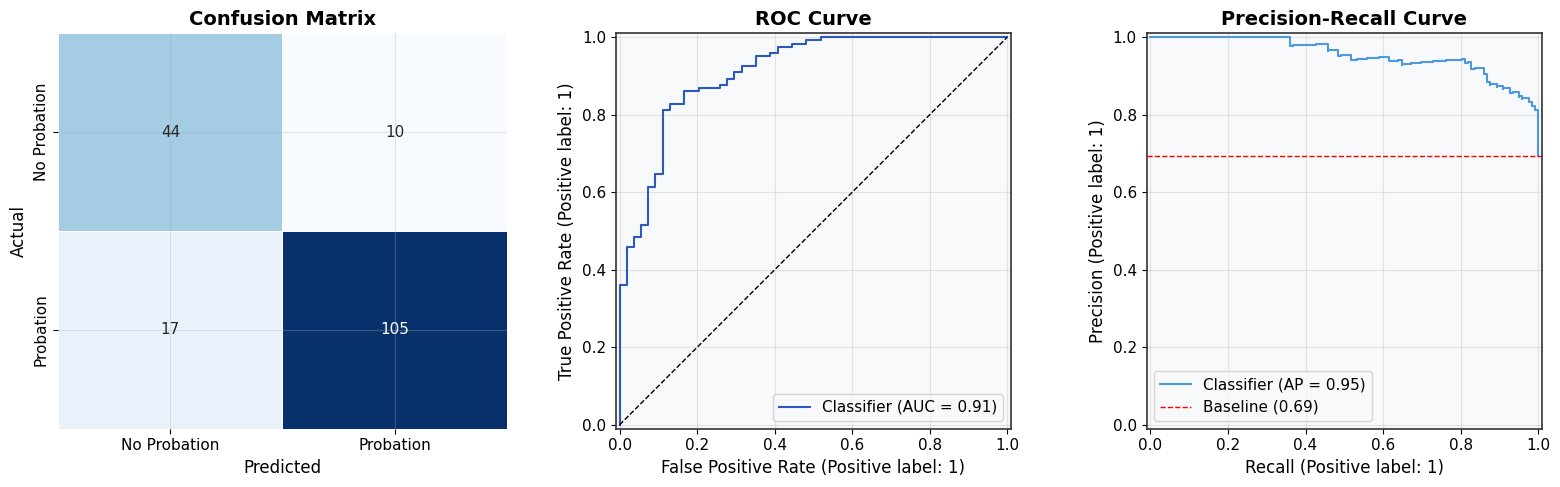

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Probation', 'Probation'],
            yticklabels=['No Probation', 'Probation'],
            linewidths=0.5, cbar=False)
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1], color=COLORS[0])
axes[1].plot([0,1],[0,1],'k--', linewidth=1)
axes[1].set_title('ROC Curve', fontweight='bold')

# Precision-Recall Curve
PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=axes[2], color=COLORS[1])
axes[2].axhline(y=y_test.mean(), color='red', linestyle='--', linewidth=1,
                label=f'Baseline ({y_test.mean():.2f})')
axes[2].legend()
axes[2].set_title('Precision-Recall Curve', fontweight='bold')

plt.tight_layout()
plt.show()

## **7. Feature Importance**

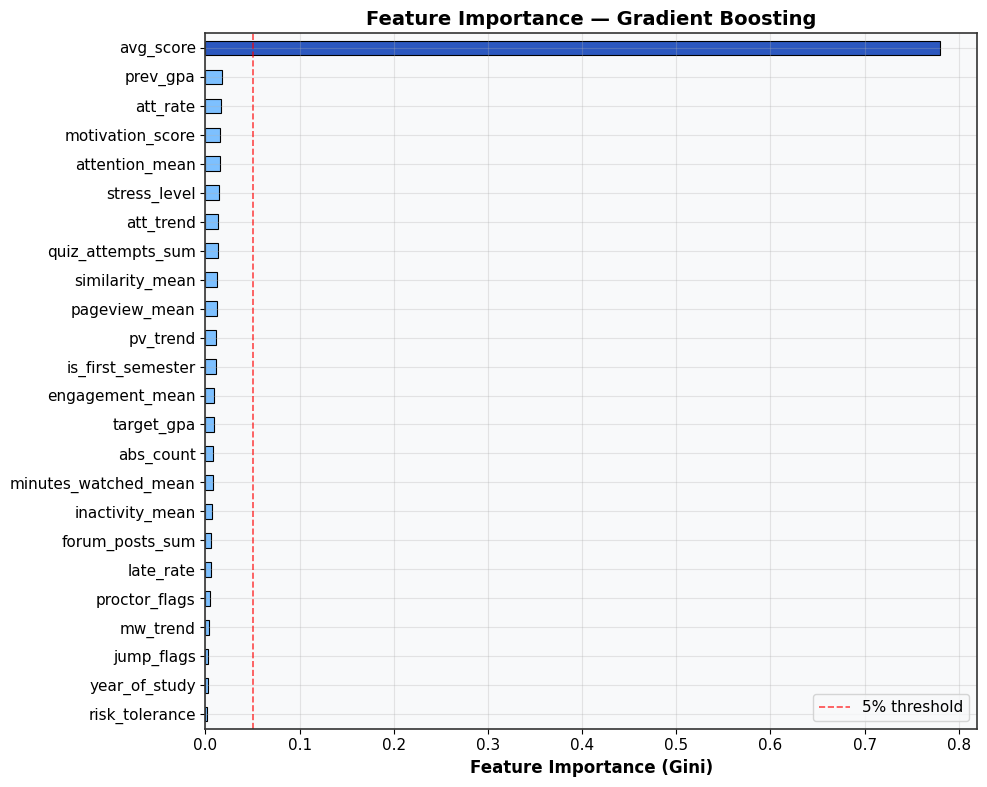


Top 10 features:
avg_score            0.7803
prev_gpa             0.0174
att_rate             0.0166
motivation_score     0.0157
attention_mean       0.0154
stress_level         0.0145
att_trend            0.0136
quiz_attempts_sum    0.0131
similarity_mean      0.0123
pageview_mean        0.0118
dtype: float64


In [23]:
# Train GBM for feature importance (tree-based importances are more interpretable)
gbm = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, random_state=CONFIG['RANDOM_SEED'])
gbm.fit(X_train, y_train)

fi = (
    pd.Series(gbm.feature_importances_, index=feature_cols)
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 8))
colors  = [COLORS[0] if v >= 0.05 else COLORS[2] for v in fi.values]
fi.plot(kind='barh', ax=ax, color=colors, edgecolor='black', linewidth=0.8)
ax.axvline(0.05, color='red', linestyle='--', linewidth=1.2, alpha=0.7, label='5% threshold')
ax.set_xlabel('Feature Importance (Gini)', fontweight='bold')
ax.set_title('Feature Importance — Gradient Boosting', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print('\nTop 10 features:')
print(fi.sort_values(ascending=False).head(10).round(4))

## **8. Save Model**

In [24]:
import joblib

bundle = {
    'model'        : best_model,
    'feature_cols' : feature_cols,
}

joblib.dump(bundle, 'student_risk_model.pkl')
print("Saved.")

Saved.
